In [2]:
import pandas as pd

# Corrected file paths using raw strings
forest_path = r"C:\Users\tanishq\Downloads\Bird_Monitoring_Data_FOREST.XLSX"
grassland_path = r"C:\Users\tanishq\Downloads\Bird_Monitoring_Data_GRASSLAND.XLSX"

# Load all sheets from Forest file
forest_excel = pd.ExcelFile(forest_path)
forest_dfs = [forest_excel.parse(sheet).assign(Habitat_Type='Forest') for sheet in forest_excel.sheet_names]
forest_combined = pd.concat(forest_dfs, ignore_index=True)

# Load all sheets from Grassland file
grassland_excel = pd.ExcelFile(grassland_path)
grassland_dfs = [grassland_excel.parse(sheet).assign(Habitat_Type='Grassland') for sheet in grassland_excel.sheet_names]
grassland_combined = pd.concat(grassland_dfs, ignore_index=True)

# Combine both into one DataFrame
combined_df = pd.concat([forest_combined, grassland_combined], ignore_index=True)

# Preview
print("Forest data shape:", forest_combined.shape)
print("Grassland data shape:", grassland_combined.shape)
print("Total combined shape:", combined_df.shape)
print("Habitat types:", combined_df['Habitat_Type'].unique())
print("\nSample data:\n", combined_df.head())



Forest data shape: (8546, 30)
Grassland data shape: (8531, 30)
Total combined shape: (17077, 32)
Habitat types: ['Forest' 'Grassland']

Sample data:
   Admin_Unit_Code Sub_Unit_Code Site_Name  Plot_Name Location_Type  Year  \
0            ANTI           NaN    ANTI 1  ANTI-0036        Forest  2018   
1            ANTI           NaN    ANTI 1  ANTI-0036        Forest  2018   
2            ANTI           NaN    ANTI 1  ANTI-0036        Forest  2018   
3            ANTI           NaN    ANTI 1  ANTI-0036        Forest  2018   
4            ANTI           NaN    ANTI 1  ANTI-0036        Forest  2018   

        Date Start_Time  End_Time          Observer  ...  \
0 2018-05-22   06:19:00  06:29:00  Elizabeth Oswald  ...   
1 2018-05-22   06:19:00  06:29:00  Elizabeth Oswald  ...   
2 2018-05-22   06:19:00  06:29:00  Elizabeth Oswald  ...   
3 2018-05-22   06:19:00  06:29:00  Elizabeth Oswald  ...   
4 2018-05-22   06:19:00  06:29:00  Elizabeth Oswald  ...   

  Regional_Stewardship_Status Te

C:\Users\tanishq\AppData\Local\Temp\ipykernel_11320\11053000.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  grassland_combined = pd.concat(grassland_dfs, ignore_index=True)


In [4]:
# Percentage of missing values per column
null_percent = (combined_df.isnull().sum() / len(combined_df)) * 100

# Sort descending for better visibility
null_percent = null_percent.sort_values(ascending=False)

# Display
print("Percentage of missing values per column:\n")
print(null_percent)


Percentage of missing values per column:

Sub_Unit_Code                  95.772091
TaxonCode                      50.055630
Previously_Obs                 50.043919
Site_Name                      49.956081
NPSTaxonCode                   49.956081
Sex                            30.350764
Distance                        8.701763
AcceptedTSN                     0.193242
ID_Method                       0.011712
Date                            0.000000
Year                            0.000000
End_Time                        0.000000
Start_Time                      0.000000
Location_Type                   0.000000
Admin_Unit_Code                 0.000000
Plot_Name                       0.000000
Flyover_Observed                0.000000
Observer                        0.000000
Visit                           0.000000
Interval_Length                 0.000000
AOU_Code                        0.000000
PIF_Watchlist_Status            0.000000
Scientific_Name                 0.000000
Common_Name    

In [5]:
cols_to_drop = ['Sub_Unit_Code', 'TaxonCode', 'Previously_Obs', 'Site_Name', 'NPSTaxonCode']
combined_df.drop(columns=cols_to_drop, inplace=True)


In [6]:
print("Shape after dropping columns:", combined_df.shape)


Shape after dropping columns: (17077, 27)


In [7]:
missing_percent = combined_df.isnull().mean() * 100
print("Missing values (%) per column:\n", missing_percent)


Missing values (%) per column:
 Admin_Unit_Code                 0.000000
Plot_Name                       0.000000
Location_Type                   0.000000
Year                            0.000000
Date                            0.000000
Start_Time                      0.000000
End_Time                        0.000000
Observer                        0.000000
Visit                           0.000000
Interval_Length                 0.000000
ID_Method                       0.011712
Distance                        8.701763
Flyover_Observed                0.000000
Sex                            30.350764
Common_Name                     0.000000
Scientific_Name                 0.000000
AcceptedTSN                     0.193242
AOU_Code                        0.000000
PIF_Watchlist_Status            0.000000
Regional_Stewardship_Status     0.000000
Temperature                     0.000000
Humidity                        0.000000
Sky                             0.000000
Wind                     

In [8]:
missing_distance_species = combined_df[combined_df['Distance'].isnull()].groupby('Scientific_Name').size()
print("Number of missing Distance values per species:\n", missing_distance_species)


Number of missing Distance values per species:
 Scientific_Name
Agelaius phoeniceus            85
Aix sponsa                      2
Anas platyrhynchos              1
Archilochus colubris            1
Ardea herodias                 16
Bombycilla cedrorum           263
Branta canadensis              19
Buteo jamaicensis               2
Buteo lineatus                  3
Butorides virescens             1
Cardinalis cardinalis           6
Carduelis tristis             101
Cathartes aura                 48
Chaetura pelagica               7
Charadrius vociferus            7
Columba livia                  11
Coragyps atratus                2
Corvus                         17
Corvus brachyrhynchos          45
Corvus ossifragus              13
Cyanocitta cristata            25
Dryocopus pileatus              2
Dumetella carolinensis          1
Falco peregrinus                1
Falco sparverius                5
Haemorhous mexicanus            5
Haliaeetus leucocephalus        5
Hirundinidae      

In [9]:
# Impute Distance with mode distance per species
combined_df['Distance'] = combined_df.groupby('Scientific_Name')['Distance'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Unknown')
)

In [10]:
# Check for any 'Unknown' values in Distance
unknown_count = (combined_df['Distance'] == 'Unknown').sum()
print(f"Number of 'Unknown' Distance entries: {unknown_count}")

# Check for any remaining missing values in Distance
missing_count = combined_df['Distance'].isnull().sum()
print(f"Number of missing Distance entries: {missing_count}")


Number of 'Unknown' Distance entries: 6
Number of missing Distance entries: 0


In [11]:
# Function to replace 'Unknown' with the most common Distance per Habitat_Type
def fill_unknown_with_habitat_mode(row):
    if row['Distance'] == 'Unknown':
        mode_val = (
            combined_df[
                (combined_df['Habitat_Type'] == row['Habitat_Type']) &
                (combined_df['Distance'] != 'Unknown')
            ]['Distance'].mode()
        )
        return mode_val.iloc[0] if not mode_val.empty else 'Unknown'
    return row['Distance']

# Apply the function row-wise
combined_df['Distance'] = combined_df.apply(fill_unknown_with_habitat_mode, axis=1)


In [12]:
print("Remaining 'Unknown' Distance entries:", (combined_df['Distance'] == 'Unknown').sum())


Remaining 'Unknown' Distance entries: 0


In [13]:
combined_df['Sex'].value_counts(dropna=False)


Sex
Undetermined    8410
NaN             5183
Male            3338
Female           146
Name: count, dtype: int64

In [14]:
# Replace NaN with 'Undetermined' safely
combined_df['Sex'] = combined_df['Sex'].fillna('Undetermined')

In [15]:
print(combined_df['Sex'].value_counts())


Sex
Undetermined    13593
Male             3338
Female            146
Name: count, dtype: int64


In [16]:
missing_percent = combined_df.isnull().mean() * 100
print("Missing values (%) per column:\n", missing_percent)

Missing values (%) per column:
 Admin_Unit_Code                0.000000
Plot_Name                      0.000000
Location_Type                  0.000000
Year                           0.000000
Date                           0.000000
Start_Time                     0.000000
End_Time                       0.000000
Observer                       0.000000
Visit                          0.000000
Interval_Length                0.000000
ID_Method                      0.011712
Distance                       0.000000
Flyover_Observed               0.000000
Sex                            0.000000
Common_Name                    0.000000
Scientific_Name                0.000000
AcceptedTSN                    0.193242
AOU_Code                       0.000000
PIF_Watchlist_Status           0.000000
Regional_Stewardship_Status    0.000000
Temperature                    0.000000
Humidity                       0.000000
Sky                            0.000000
Wind                           0.000000
Disturba

In [17]:
for col in ['ID_Method', 'AcceptedTSN']:
    mode_val = combined_df[col].mode()[0]
    combined_df[col] = combined_df[col].fillna(mode_val)

In [18]:
missing_percent = combined_df.isnull().mean() * 100
print("Missing values (%) per column:\n", missing_percent)

Missing values (%) per column:
 Admin_Unit_Code                0.0
Plot_Name                      0.0
Location_Type                  0.0
Year                           0.0
Date                           0.0
Start_Time                     0.0
End_Time                       0.0
Observer                       0.0
Visit                          0.0
Interval_Length                0.0
ID_Method                      0.0
Distance                       0.0
Flyover_Observed               0.0
Sex                            0.0
Common_Name                    0.0
Scientific_Name                0.0
AcceptedTSN                    0.0
AOU_Code                       0.0
PIF_Watchlist_Status           0.0
Regional_Stewardship_Status    0.0
Temperature                    0.0
Humidity                       0.0
Sky                            0.0
Wind                           0.0
Disturbance                    0.0
Initial_Three_Min_Cnt          0.0
Habitat_Type                   0.0
dtype: float64


In [19]:
combined_df.shape

(17077, 27)

In [20]:
print(combined_df.isnull().mean() * 100)


Admin_Unit_Code                0.0
Plot_Name                      0.0
Location_Type                  0.0
Year                           0.0
Date                           0.0
Start_Time                     0.0
End_Time                       0.0
Observer                       0.0
Visit                          0.0
Interval_Length                0.0
ID_Method                      0.0
Distance                       0.0
Flyover_Observed               0.0
Sex                            0.0
Common_Name                    0.0
Scientific_Name                0.0
AcceptedTSN                    0.0
AOU_Code                       0.0
PIF_Watchlist_Status           0.0
Regional_Stewardship_Status    0.0
Temperature                    0.0
Humidity                       0.0
Sky                            0.0
Wind                           0.0
Disturbance                    0.0
Initial_Three_Min_Cnt          0.0
Habitat_Type                   0.0
dtype: float64


In [21]:
duplicate_count = combined_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")


Number of duplicate rows: 1709


In [22]:
duplicates = combined_df[combined_df.duplicated()]
print(duplicates)

      Admin_Unit_Code  Plot_Name Location_Type  Year       Date Start_Time  \
2234             CHOH  CHOH-1256        Forest  2018 2018-06-13   08:17:00   
3532             GWMP  GWMP-0120        Forest  2018 2018-06-29   09:40:00   
5558             NACE  NACE-0477        Forest  2018 2018-05-11   08:57:00   
7166             PRWI  PRWI-0660        Forest  2018 2018-07-03   09:00:00   
8553             ANTI  ANTI-0054     Grassland  2018 2018-05-22   05:35:00   
...               ...        ...           ...   ...        ...        ...   
17072            MONO  MONO-0089     Grassland  2018 2018-05-10   06:35:00   
17073            MONO  MONO-0089     Grassland  2018 2018-05-10   06:35:00   
17074            MONO  MONO-0089     Grassland  2018 2018-05-10   06:35:00   
17075            MONO  MONO-0089     Grassland  2018 2018-05-10   06:35:00   
17076            MONO  MONO-0089     Grassland  2018 2018-05-10   06:35:00   

       End_Time          Observer Visit Interval_Length  ... AO

In [23]:
duplicate_groups = combined_df[combined_df.duplicated(keep=False)]
num_unique_duplicate_groups = duplicate_groups.drop_duplicates().shape[0]
print(f"Number of unique duplicate groups: {num_unique_duplicate_groups}")


Number of unique duplicate groups: 751


In [24]:
combined_df.drop_duplicates(inplace=True)


In [25]:
print("Shape after dropping duplicates:", combined_df.shape)


Shape after dropping duplicates: (15368, 27)


In [26]:
[combined_df['Habitat_Type'] == 'Grassland']

[0        False
 1        False
 2        False
 3        False
 4        False
          ...  
 17060     True
 17061     True
 17062     True
 17063     True
 17067     True
 Name: Habitat_Type, Length: 15368, dtype: bool]

In [27]:
import mysql.connector

# Step 1: Connect to MySQL (no database yet)
connection = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password="123456789"
)

# Step 2: Create a cursor
cursor = connection.cursor()

# Step 3: Create the new database
cursor.execute("CREATE DATABASE IF NOT EXISTS forest_grassland")

# Step 4: Confirm
print("Database 'forest_grassland' created or already exists.")

# Step 5: Optional — switch to new database for future operations
cursor.execute("USE forest_grassland")
print(" Now using database: forest_grassland")


Database 'forest_grassland' created or already exists.
 Now using database: forest_grassland


In [28]:
# Check data types
print(combined_df.dtypes)

# Optional: check unique values for categorical columns
categorical_cols = combined_df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\n{col} - unique values:\n", combined_df[col].unique())


Admin_Unit_Code                        object
Plot_Name                              object
Location_Type                          object
Year                                   object
Date                           datetime64[ns]
Start_Time                             object
End_Time                               object
Observer                               object
Visit                                  object
Interval_Length                        object
ID_Method                              object
Distance                               object
Flyover_Observed                       object
Sex                                    object
Common_Name                            object
Scientific_Name                        object
AcceptedTSN                           float64
AOU_Code                               object
PIF_Watchlist_Status                   object
Regional_Stewardship_Status            object
Temperature                           float64
Humidity                          

In [29]:
print(combined_df['Flyover_Observed'].unique())


[False True]


In [36]:
combined_df['Interval_Length'].head()


0    2.5
1    2.5
2    5.0
3    5.0
4    5.0
Name: Interval_Length, dtype: float64

<Axes: title={'center': 'Number of Species per Admin Unit'}, xlabel='Admin_Unit_Code'>

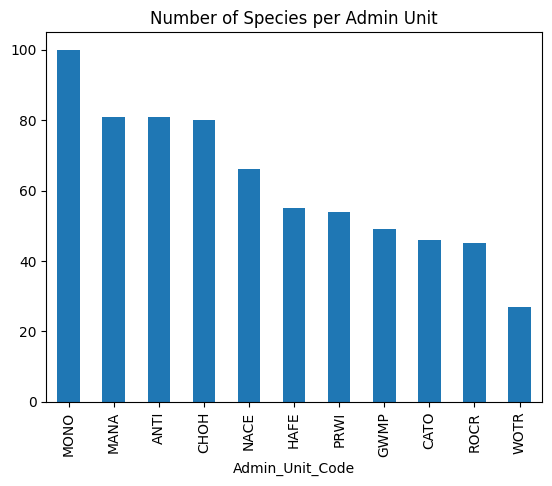

In [37]:
species_per_admin = combined_df.groupby('Admin_Unit_Code')['Scientific_Name'].nunique().sort_values(ascending=False)
species_per_admin.plot(kind='bar', title='Number of Species per Admin Unit')


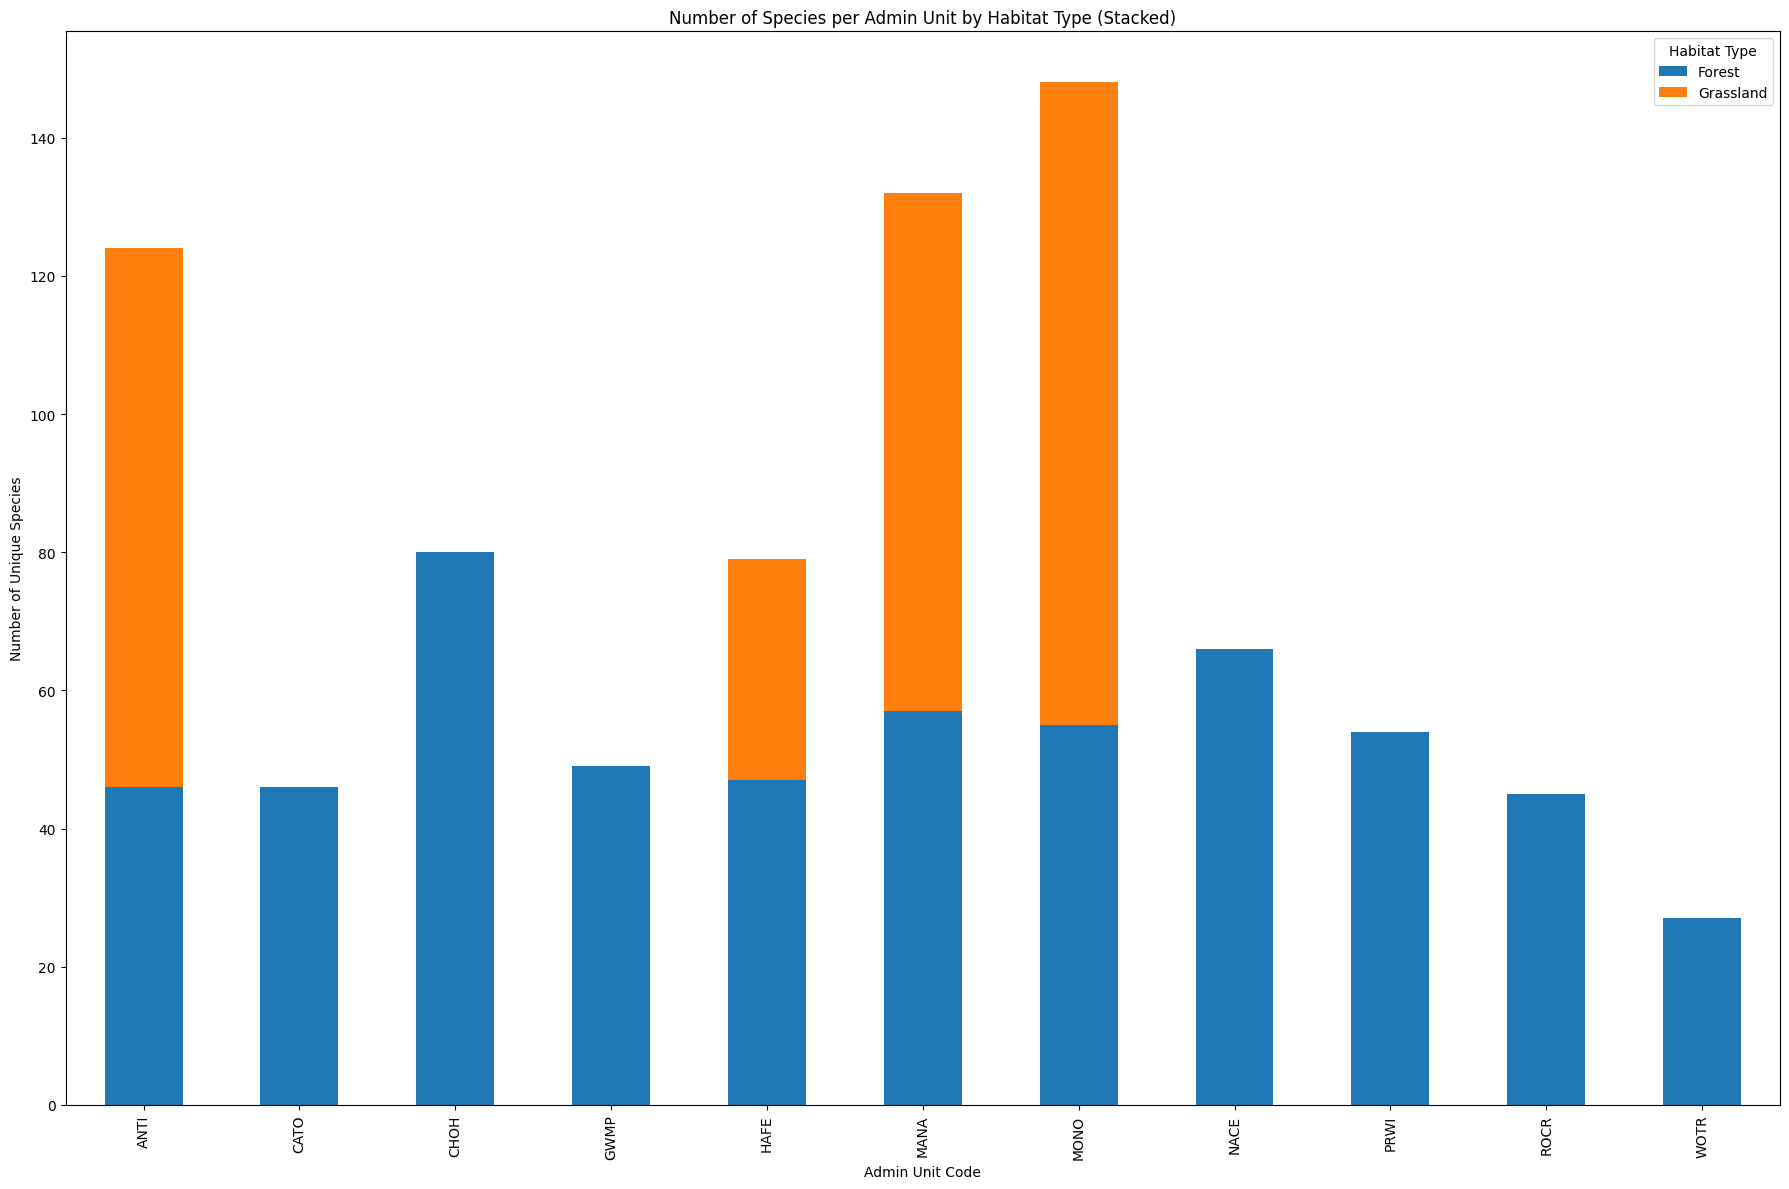

In [69]:
species_admin_habitat.plot(kind='bar', stacked=True, figsize=(18,12))
plt.title('Number of Species per Admin Unit by Habitat Type (Stacked)')
plt.xlabel('Admin Unit Code')
plt.ylabel('Number of Unique Species')
plt.legend(title='Habitat Type')
plt.tight_layout()
plt.show()


<Axes: xlabel='Habitat_Type', ylabel='Admin_Unit_Code'>

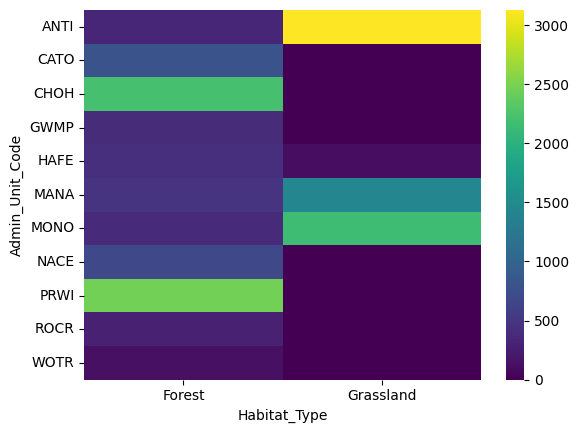

In [43]:
import seaborn as sns
freq_matrix = pd.crosstab(combined_df['Admin_Unit_Code'], combined_df['Habitat_Type'])
sns.heatmap(freq_matrix, cmap='viridis')


In [52]:
top_species_habitat = combined_df.groupby(['Habitat_Type', 'Scientific_Name']).size().groupby(level=0, group_keys=False).nlargest(10)
print(top_species_habitat)


Habitat_Type  Scientific_Name         
Forest        Vireo olivaceus             693
              Thryothorus ludovicianus    646
              Cardinalis cardinalis       595
              Baeolophus bicolor          541
              Contopus virens             486
              Empidonax virescens         436
              Melanerpes carolinus        397
              Polioptila caerulea         310
              Seiurus aurocapillus        303
              Turdus migratorius          294
Grassland     Cardinalis cardinalis       530
              Passerina cyanea            461
              Spizella pusilla            456
              Spizella passerina          353
              Thryothorus ludovicianus    347
              Ammodramus savannarum       346
              Carduelis tristis           310
              Agelaius phoeniceus         273
              Melospiza melodia           222
              Zenaida macroura            197
dtype: int64


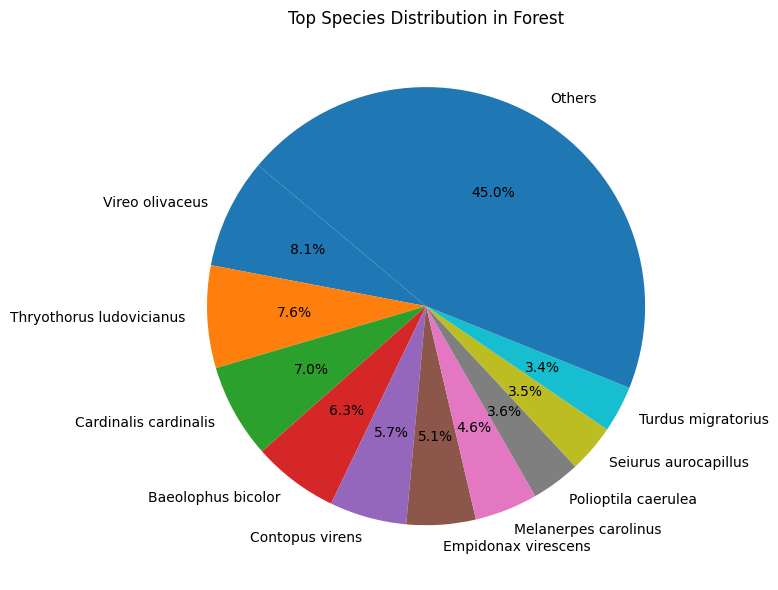

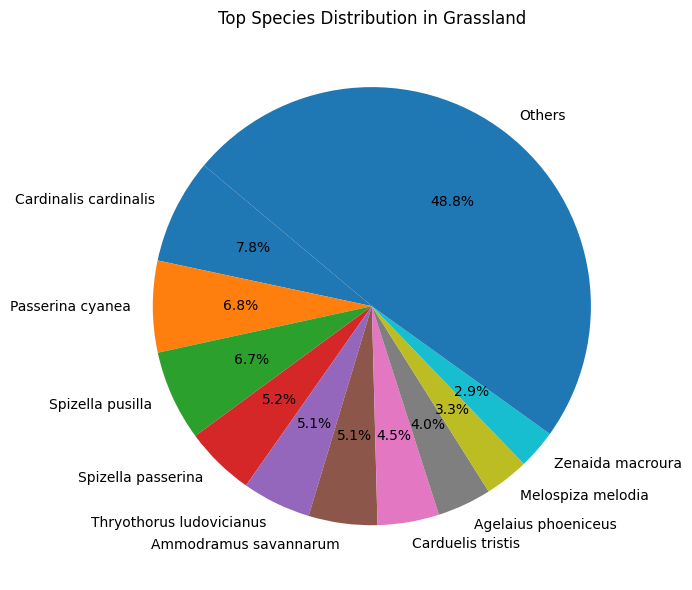

In [57]:
import matplotlib.pyplot as plt

# Get unique habitat types (no need to dropna since data is clean)
habitats = combined_df['Habitat_Type'].unique()

for habitat in habitats:
    # Filter data by habitat type
    habitat_df = combined_df[combined_df['Habitat_Type'] == habitat]
    
    # Count occurrences of each species
    species_counts = habitat_df['Scientific_Name'].value_counts()
    
    # Separate top 10 species and group the rest as "Others"
    top_species = species_counts.head(10)
    others = species_counts[10:].sum()
    
    # Combine top species and others
    pie_data = top_species.copy()
    if others > 0:
        pie_data['Others'] = others

    # Plotting the pie chart
    plt.figure(figsize=(8, 6))
    pie_data.plot.pie(autopct='%1.1f%%', startangle=140)
    plt.title(f'Top Species Distribution in {habitat}')
    plt.ylabel('')  # Hide y-label
    plt.tight_layout()
    plt.show()


In [67]:
for col in combined_df.columns:
    print(col)


Admin_Unit_Code
Plot_Name
Location_Type
Year
Date
Start_Time
End_Time
Observer
Visit
Interval_Length
ID_Method
Distance
Flyover_Observed
Sex
Common_Name
Scientific_Name
AcceptedTSN
AOU_Code
PIF_Watchlist_Status
Regional_Stewardship_Status
Temperature
Humidity
Sky
Wind
Disturbance
Initial_Three_Min_Cnt
Habitat_Type


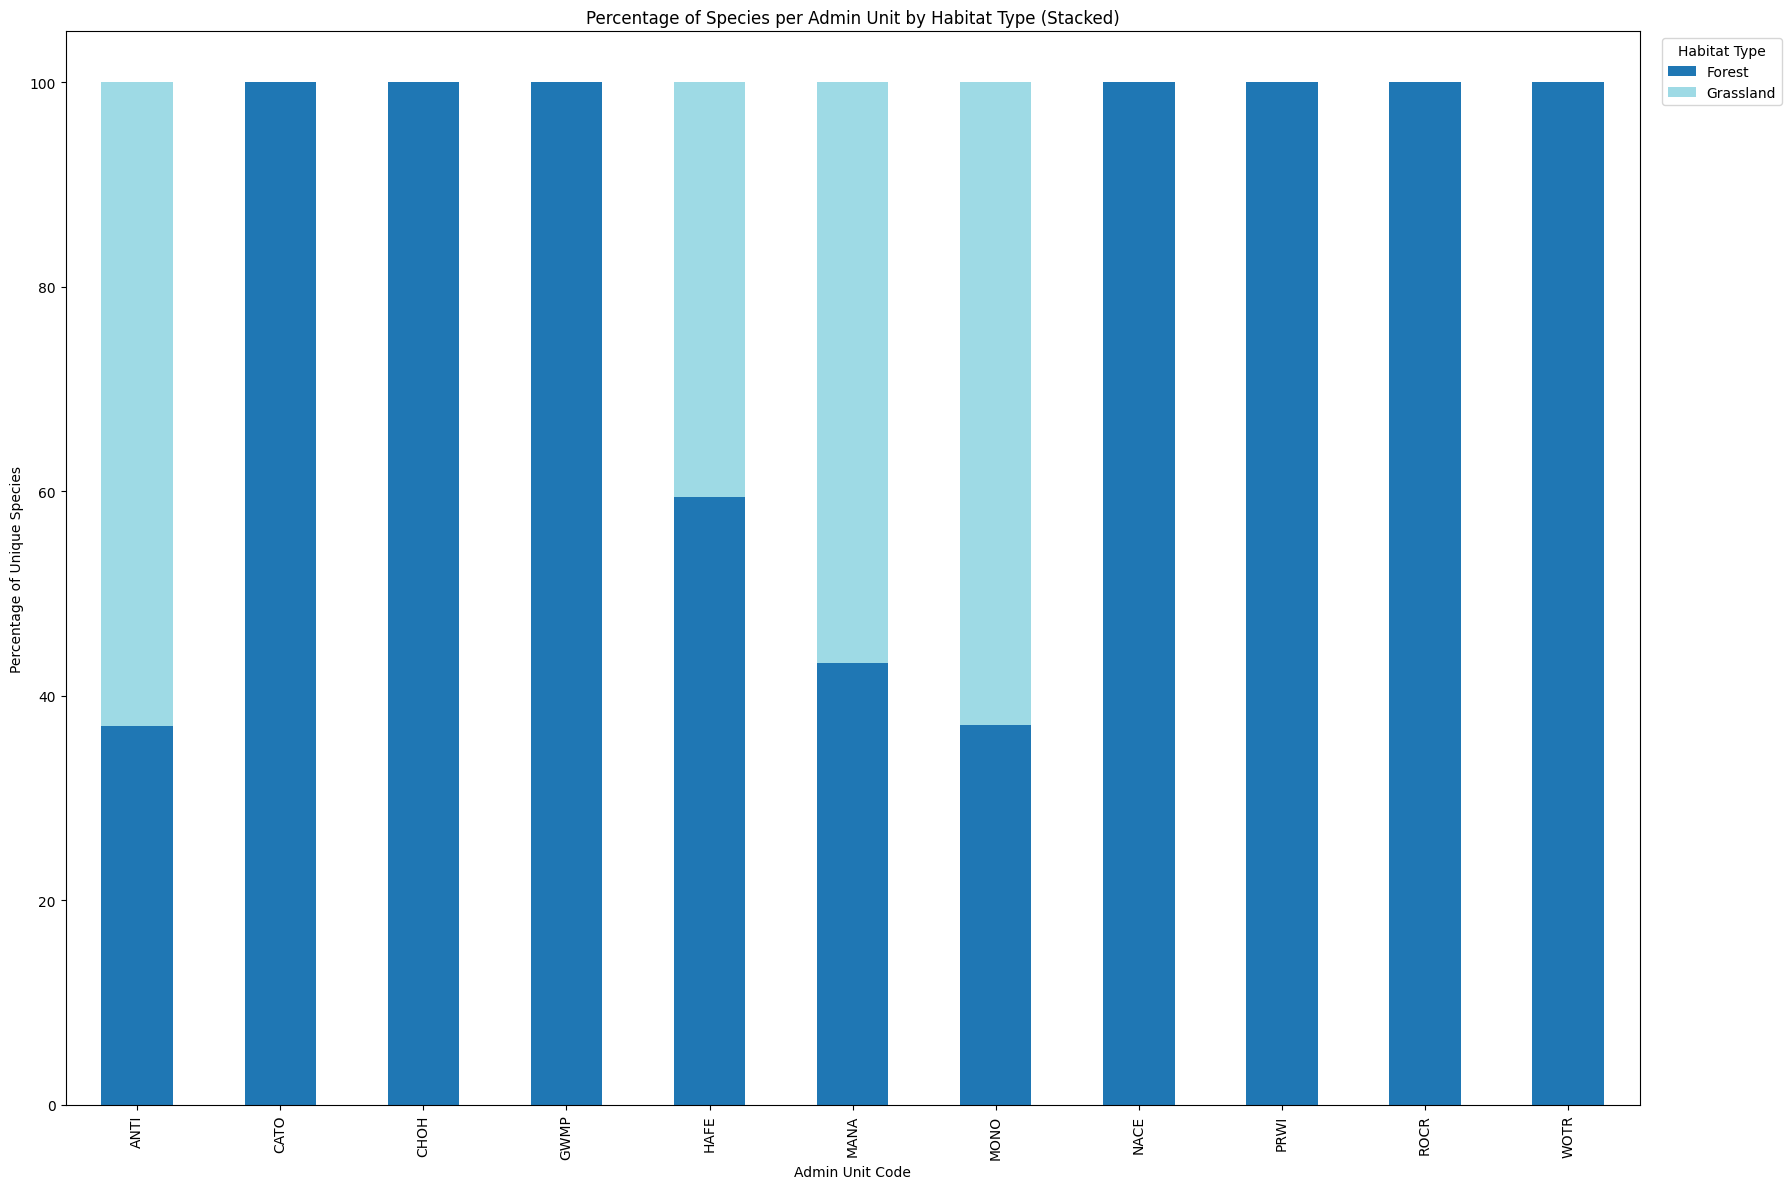

In [71]:
import matplotlib.pyplot as plt

# Normalize the values row-wise to get percentages
species_admin_habitat_percent = species_admin_habitat.div(species_admin_habitat.sum(axis=1), axis=0) * 100

# Plot the percentage stacked bar chart
ax = species_admin_habitat_percent.plot(kind='bar', stacked=True, figsize=(18, 12), colormap='tab20')
plt.title('Percentage of Species per Admin Unit by Habitat Type (Stacked)')
plt.xlabel('Admin Unit Code')
plt.ylabel('Percentage of Unique Species')
plt.legend(title='Habitat Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [72]:
combined_df.to_csv(r"C:\Users\tanishq\Desktop\_project2\cleaned_combined_df.csv", index=False)


In [1]:
import pandas as pd

# Read the cleaned data from the CSV file
combined_df = pd.read_csv(r"C:\Users\tanishq\Desktop\_project2\cleaned_combined_df.csv")

# Preview to confirm
print(combined_df.head())


  Admin_Unit_Code  Plot_Name Location_Type  Year        Date Start_Time  \
0            ANTI  ANTI-0036        Forest  2018  2018-05-22   06:19:00   
1            ANTI  ANTI-0036        Forest  2018  2018-05-22   06:19:00   
2            ANTI  ANTI-0036        Forest  2018  2018-05-22   06:19:00   
3            ANTI  ANTI-0036        Forest  2018  2018-05-22   06:19:00   
4            ANTI  ANTI-0036        Forest  2018  2018-05-22   06:19:00   

   End_Time          Observer  Visit  Interval_Length  ... AOU_Code  \
0  06:29:00  Elizabeth Oswald      1              2.5  ...     EATO   
1  06:29:00  Elizabeth Oswald      1              2.5  ...     WBNU   
2  06:29:00  Elizabeth Oswald      1              5.0  ...     RBWO   
3  06:29:00  Elizabeth Oswald      1              5.0  ...     OROR   
4  06:29:00  Elizabeth Oswald      1              5.0  ...     NOMO   

  PIF_Watchlist_Status  Regional_Stewardship_Status Temperature   Humidity  \
0                False                      

In [2]:
# Ensure 'Date' column is in datetime format (just in case)
combined_df['Date'] = pd.to_datetime(combined_df['Date'])

# Extract month from 'Date'
combined_df['Month'] = combined_df['Date'].dt.month

# Define function to map month to season
def get_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return 'Winter'

# Create 'Season' column
combined_df['Season'] = combined_df['Month'].apply(get_season)


In [7]:
combined_df[['Date', 'Month', 'Season']].head(300)


,Date,Month,Season
0,2018-05-22,5,Spring
1,2018-05-22,5,Spring
2,2018-05-22,5,Spring
3,2018-05-22,5,Spring
4,2018-05-22,5,Spring
...,...,...,...
295,2018-06-26,6,Summer
296,2018-06-26,6,Summer
297,2018-06-26,6,Summer
298,2018-06-26,6,Summer


Season
Summer    10505
Spring     4863
Name: count, dtype: int64


<Axes: title={'center': 'Observation Counts by Season'}, xlabel='Season'>

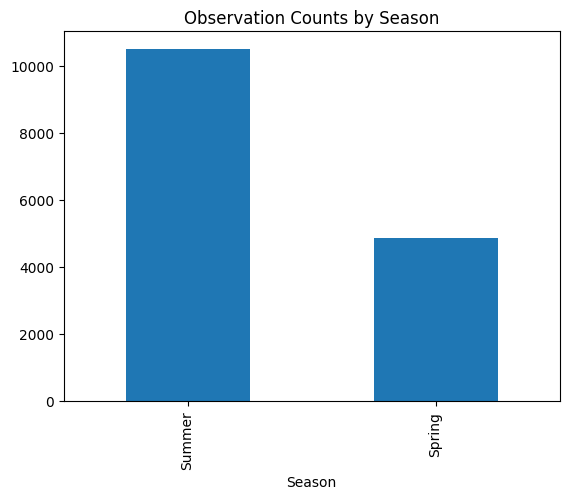

In [9]:
season_counts = combined_df['Season'].value_counts()
print(season_counts)
season_counts.plot(kind='bar', title='Observation Counts by Season')


Season
Spring    114
Summer    107
Name: Scientific_Name, dtype: int64


<Axes: title={'center': 'Unique Species per Season'}, xlabel='Season'>

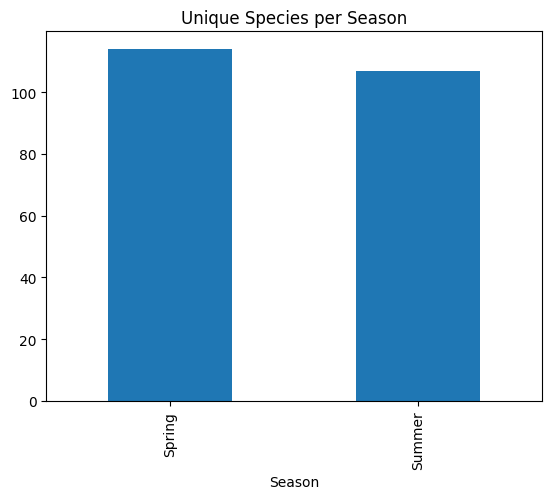

In [10]:
species_per_season = combined_df.groupby('Season')['Scientific_Name'].nunique()
print(species_per_season)
species_per_season.plot(kind='bar', title='Unique Species per Season')


        Temperature   Humidity
Season                        
Spring    21.058976  71.359243
Summer    23.157258  75.453260


<Axes: title={'center': 'Mean Temperature and Humidity by Season'}, xlabel='Season'>

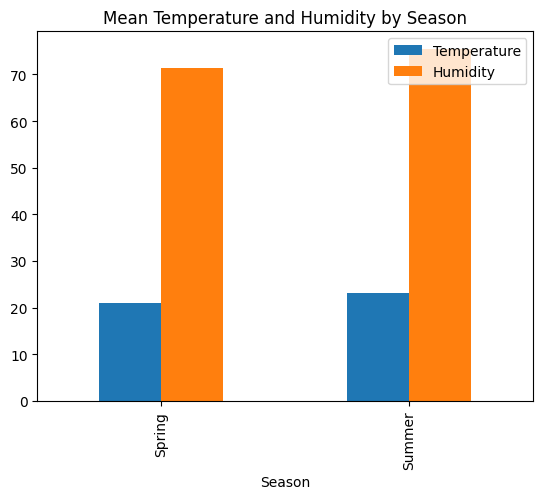

In [11]:
env_by_season = combined_df.groupby('Season')[['Temperature', 'Humidity']].mean()
print(env_by_season)
env_by_season.plot(kind='bar', title='Mean Temperature and Humidity by Season')


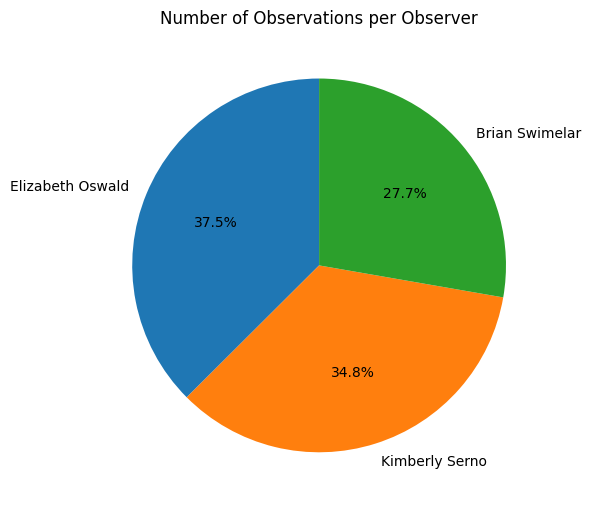

In [18]:
import matplotlib.pyplot as plt

obs_per_observer = combined_df['Observer'].value_counts()
plt.figure(figsize=(6,6))
obs_per_observer.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Number of Observations per Observer')
plt.ylabel('')  # No ylabel needed for pie chart
plt.tight_layout()
plt.show()


In [21]:
unique_visits = combined_df['Visit'].value_counts().sort_index()
print(unique_visits)


Visit
1    6854
2    6408
3    2106
Name: count, dtype: int64


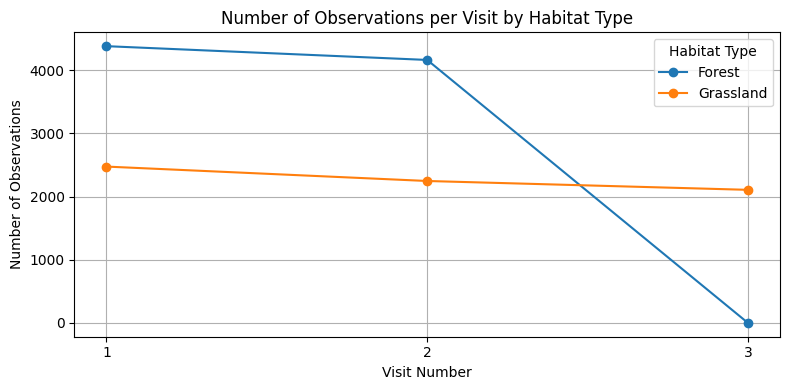

In [23]:
import matplotlib.pyplot as plt

# Group by Visit and Habitat_Type to count observations
obs_visit_habitat = combined_df.groupby(['Visit', 'Habitat_Type']).size().unstack(fill_value=0)

# Plotting
plt.figure(figsize=(8,4))
for habitat in obs_visit_habitat.columns:
    plt.plot(obs_visit_habitat.index, obs_visit_habitat[habitat], marker='o', label=habitat)

plt.title('Number of Observations per Visit by Habitat Type')
plt.xlabel('Visit Number')
plt.ylabel('Number of Observations')
plt.xticks(obs_visit_habitat.index)
plt.legend(title='Habitat Type')
plt.grid(True)
plt.tight_layout()
plt.show()


In [27]:
print(combined_df['Season'].value_counts())


Season
Summer    10505
Spring     4863
Name: count, dtype: int64


In [29]:
combined_df.shape

(15368, 29)

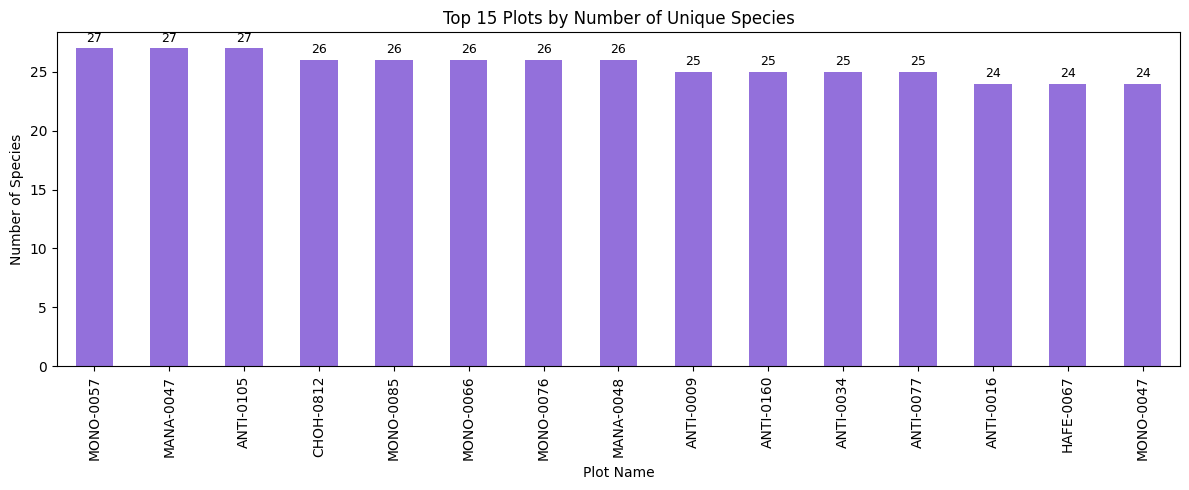

In [36]:
import matplotlib.pyplot as plt


# Species richness per plot
species_per_plot = combined_df.groupby('Plot_Name')['Scientific_Name'].nunique().sort_values(ascending=False).head(15)

plt.figure(figsize=(12,5))
ax = species_per_plot.plot(kind='bar', color='mediumpurple')
plt.title('Top 15 Plots by Number of Unique Species')
plt.xlabel('Plot Name')
plt.ylabel('Number of Species')

# Add value labels on bars
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 0.3, 
            int(p.get_height()), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()



Unique species count per habitat:
Habitat_Type
Forest       108
Grassland    107
Name: Scientific_Name, dtype: int64


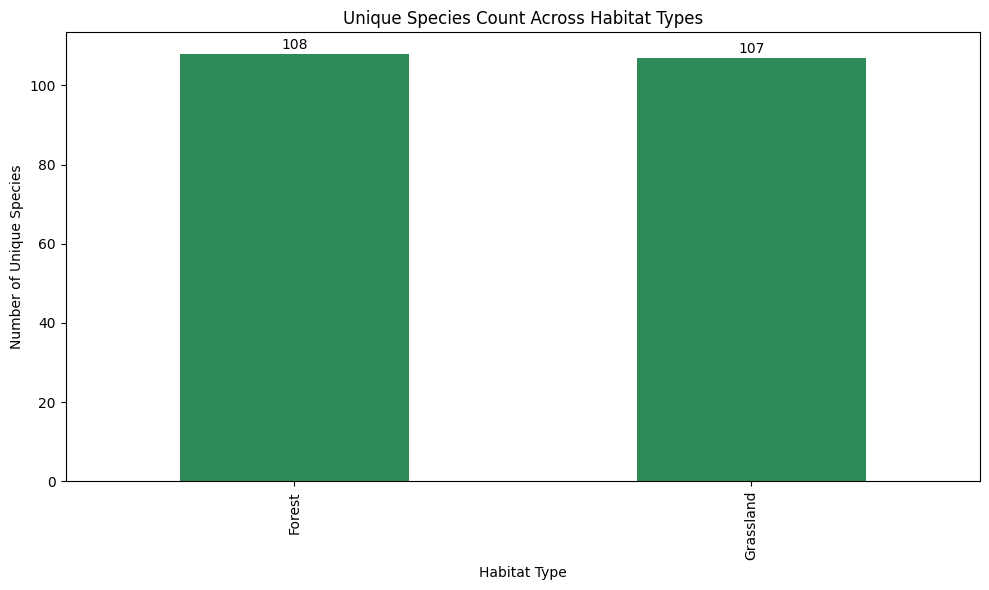

In [37]:
import matplotlib.pyplot as plt

# Count of unique species per Habitat_Type
unique_species_per_habitat = combined_df.groupby('Habitat_Type')['Scientific_Name'].nunique().sort_values(ascending=False)

print("Unique species count per habitat:")
print(unique_species_per_habitat)

# Plotting the species diversity per habitat type
plt.figure(figsize=(10,6))
ax = unique_species_per_habitat.plot(kind='bar', color='seagreen')
plt.title('Unique Species Count Across Habitat Types')
plt.xlabel('Habitat Type')
plt.ylabel('Number of Unique Species')

# Add labels on bars
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.5, 
            int(p.get_height()), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


Interval Length Distribution:
Interval_Length
2.5     7752
5.0     3149
7.5     2386
10.0    2081
Name: count, dtype: int64


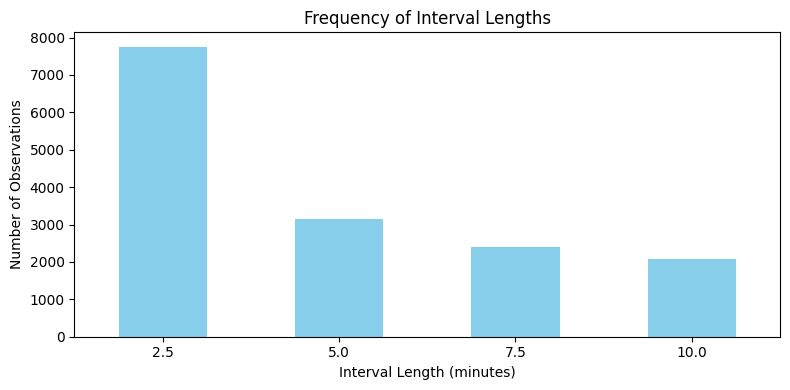

In [38]:
# Distribution of Interval_Length (e.g., durations)
interval_counts = combined_df['Interval_Length'].value_counts().sort_index()
print("Interval Length Distribution:")
print(interval_counts)

plt.figure(figsize=(8,4))
interval_counts.plot(kind='bar', color='skyblue')
plt.title('Frequency of Interval Lengths')
plt.xlabel('Interval Length (minutes)')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



Identification Method Distribution:
ID_Method
Singing          9622
Calling          3940
Visualization    1806
Name: count, dtype: int64


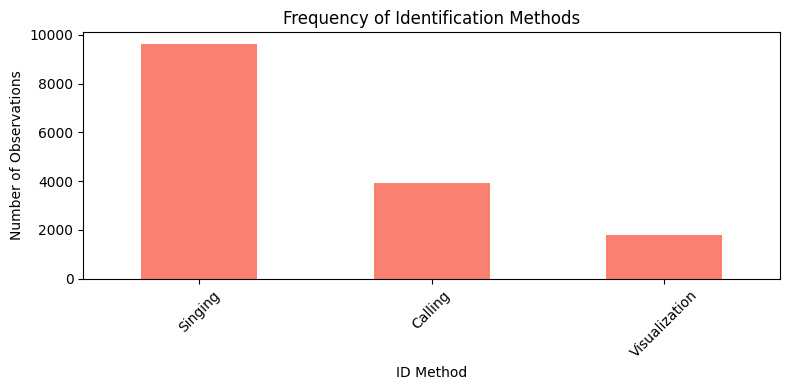

In [39]:
# Distribution of Identification Methods
id_method_counts = combined_df['ID_Method'].value_counts()
print("\nIdentification Method Distribution:")
print(id_method_counts)

plt.figure(figsize=(8,4))
id_method_counts.plot(kind='bar', color='salmon')
plt.title('Frequency of Identification Methods')
plt.xlabel('ID Method')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:

# Cross-tabulate Interval_Length and ID_Method to see patterns
activity_crosstab = pd.crosstab(combined_df['Interval_Length'], combined_df['ID_Method'])
print("\nActivity Patterns (Interval Length vs ID Method):")
print(activity_crosstab)


Activity Patterns (Interval Length vs ID Method):
ID_Method        Calling  Singing  Visualization
Interval_Length                                 
2.5                 1725     5481            546
5.0                  955     1808            386
7.5                  680     1256            450
10.0                 580     1077            424


Sex                       Female  Male  Undetermined  Sex_Ratio
Scientific_Name                                                
Cardinalis cardinalis         20    69          1036   0.775281
Thryothorus ludovicianus       0     0           993        NaN
Vireo olivaceus                0    44           693   1.000000
Baeolophus bicolor             0     7           713   1.000000
Passerina cyanea               6   450           155   0.986842
Contopus virens                0    88           486   1.000000
Spizella pusilla               0   443            49   1.000000
Melanerpes carolinus           2     3           483   0.600000
Turdus migratorius             2    81           387   0.975904
Empidonax virescens            0     0           462        NaN
Spizella passerina             0   330            81   1.000000
Polioptila caerulea            0     2           402   1.000000
Poecile carolinensis           0    49           316   1.000000
Zenaida macroura               0     1  

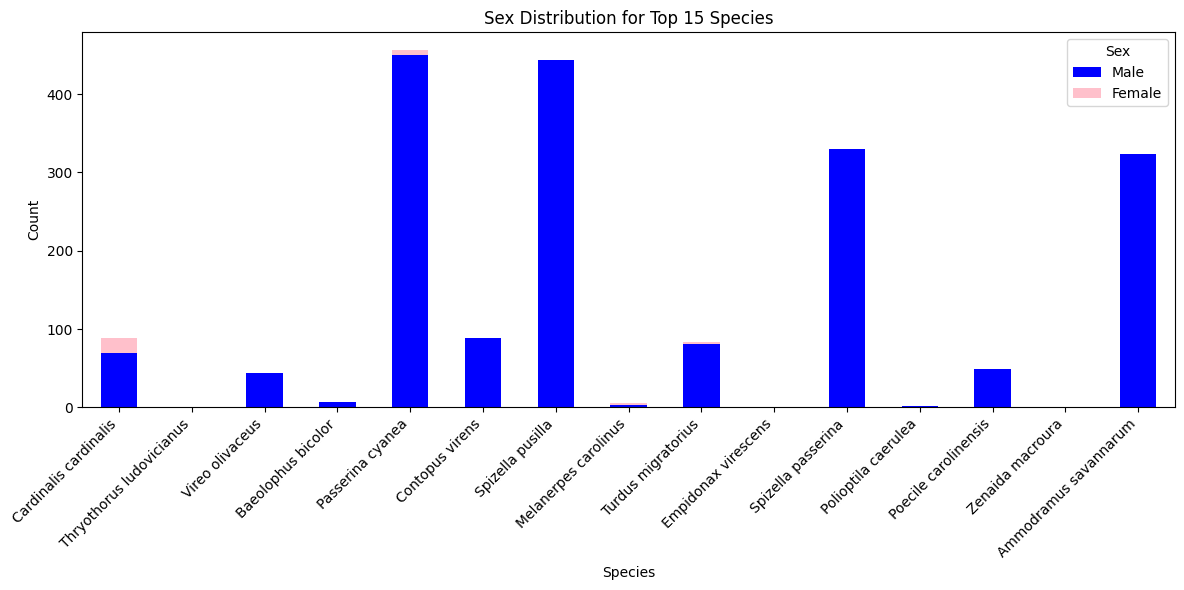

In [41]:
import matplotlib.pyplot as plt

# Count males and females per species
sex_counts = combined_df.groupby(['Scientific_Name', 'Sex']).size().unstack(fill_value=0)

# Calculate the sex ratio (e.g., Male / (Male + Female))
sex_counts['Sex_Ratio'] = sex_counts.get('Male', 0) / (sex_counts.get('Male', 0) + sex_counts.get('Female', 0))

# Show top species by total observations with sex counts
top_species = sex_counts.sum(axis=1).sort_values(ascending=False).head(15).index
sex_counts_top = sex_counts.loc[top_species]

print(sex_counts_top)

# Plot male and female counts for top 10 species
sex_counts_top[['Male', 'Female']].plot(kind='bar', stacked=True, figsize=(12,6), color=['blue', 'pink'])
plt.title('Sex Distribution for Top 15 Species')
plt.ylabel('Count')
plt.xlabel('Species')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [45]:
print(combined_df['Distance'].value_counts())



Distance
50 - 100 Meters    8080
<= 50 Meters       7288
Name: count, dtype: int64


In [2]:
import pandas as pd

# Read the cleaned dataset
combined_df = pd.read_csv(r"C:\Users\tanishq\Desktop\_project2\cleaned_combined_df.csv")


In [6]:
combined_df.head(1)

,Admin_Unit_Code,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,Visit,Interval_Length,...,AOU_Code,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt,Habitat_Type
0,ANTI,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,2.5,...,EATO,False,True,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,Forest


In [5]:
# Check unique values in 'Sky' column
combined_df['Sky'].value_counts()


Sky
Partly Cloudy          6172
Clear or Few Clouds    5330
Cloudy/Overcast        2916
Fog                     598
Mist/Drizzle            352
Name: count, dtype: int64

In [9]:
# Group by Sky and count observations
sky_counts = combined_df['Sky'].value_counts().reset_index()
sky_counts.columns = ['Sky_Condition', 'Observation_Count']
print("Bird Observations by Sky Condition:\n", sky_counts)

# Group by Wind
wind_counts = combined_df['Wind'].value_counts().reset_index()
wind_counts.columns = ['Wind_Condition', 'Observation_Count']
print("\nBird Observations by Wind Condition:\n", wind_counts)


Bird Observations by Sky Condition:
          Sky_Condition  Observation_Count
0        Partly Cloudy               6172
1  Clear or Few Clouds               5330
2      Cloudy/Overcast               2916
3                  Fog                598
4         Mist/Drizzle                352

Bird Observations by Wind Condition:
                                Wind_Condition  Observation_Count
0   Light air movement (1-3 mph) smoke drifts               7635
1       Calm (< 1 mph) smoke rises vertically               4210
2    Light breeze (4-7 mph) wind felt on face               3159
3  Gentle breeze (8-12 mph), leaves in motion                364


In [12]:
combined_df.shape

(15368, 27)

C:\Users\tanishq\AppData\Local\Temp\ipykernel_17916\2627587047.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sky_counts, x='Observation_Count', y='Sky_Condition', palette='magma')


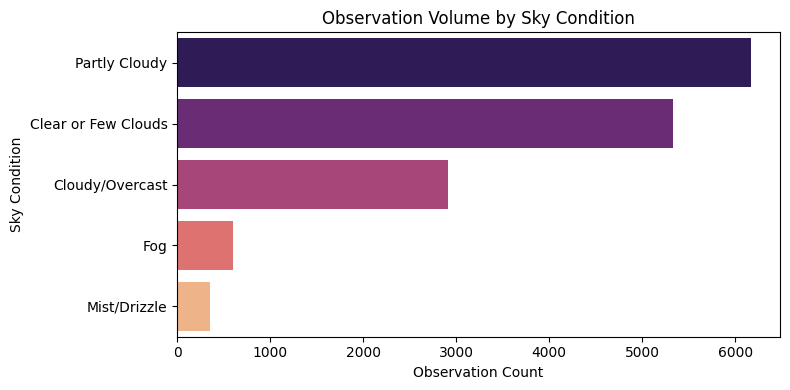

In [14]:

# Sky Condition Plot
plt.figure(figsize=(8, 4))
sns.barplot(data=sky_counts, x='Observation_Count', y='Sky_Condition', palette='magma')
plt.title("Observation Volume by Sky Condition")
plt.xlabel("Observation Count")
plt.ylabel("Sky Condition")
plt.tight_layout()
plt.show()

C:\Users\tanishq\AppData\Local\Temp\ipykernel_17916\2458571864.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=wind_counts, x='Observation_Count', y='Wind_Condition', palette='YlGn')


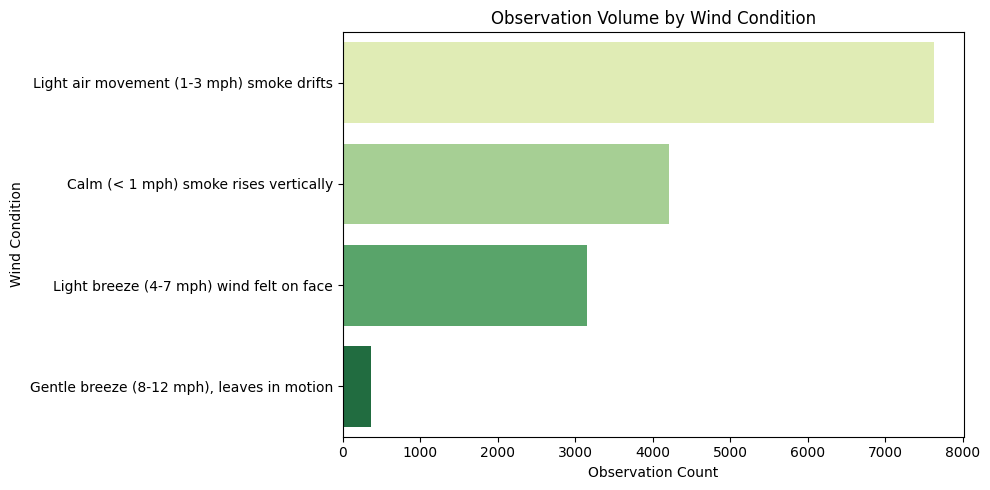

In [15]:
# Wind Condition Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=wind_counts, x='Observation_Count', y='Wind_Condition', palette='YlGn')
plt.title("Observation Volume by Wind Condition")
plt.xlabel("Observation Count")
plt.ylabel("Wind Condition")
plt.tight_layout()
plt.show()

Observation Count by Disturbance Type:
            Disturbance_Type  Observation_Count
0        No effect on count               7525
1    Slight effect on count               5836
2  Moderate effect on count               1577
3   Serious effect on count                430


C:\Users\tanishq\AppData\Local\Temp\ipykernel_17916\1694549889.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=disturbance_effect, x='Observation_Count', y='Disturbance_Type', palette='Reds_r')


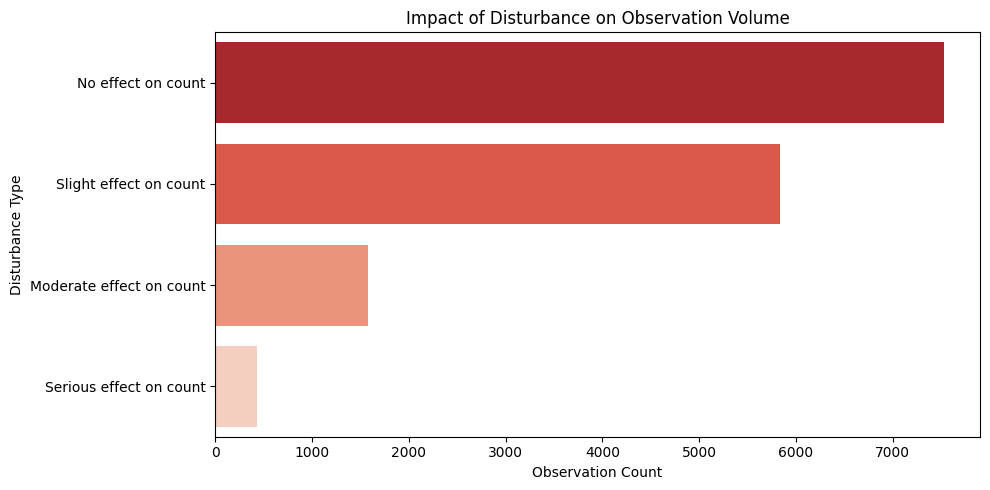

In [17]:
# Group by Disturbance category and count
disturbance_effect = combined_df['Disturbance'].value_counts().reset_index()
disturbance_effect.columns = ['Disturbance_Type', 'Observation_Count']
print("Observation Count by Disturbance Type:\n", disturbance_effect)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=disturbance_effect, x='Observation_Count', y='Disturbance_Type', palette='Reds_r')
plt.title("Impact of Disturbance on Observation Volume")
plt.xlabel("Observation Count")
plt.ylabel("Disturbance Type")
plt.tight_layout()
plt.show()


C:\Users\tanishq\AppData\Local\Temp\ipykernel_17916\4283893012.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_group_counts = combined_df.groupby('Temp_Group').size().reset_index(name='Observation_Count')
C:\Users\tanishq\AppData\Local\Temp\ipykernel_17916\4283893012.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp_group_counts, x='Observation_Count', y='Temp_Group_Label', palette='viridis')


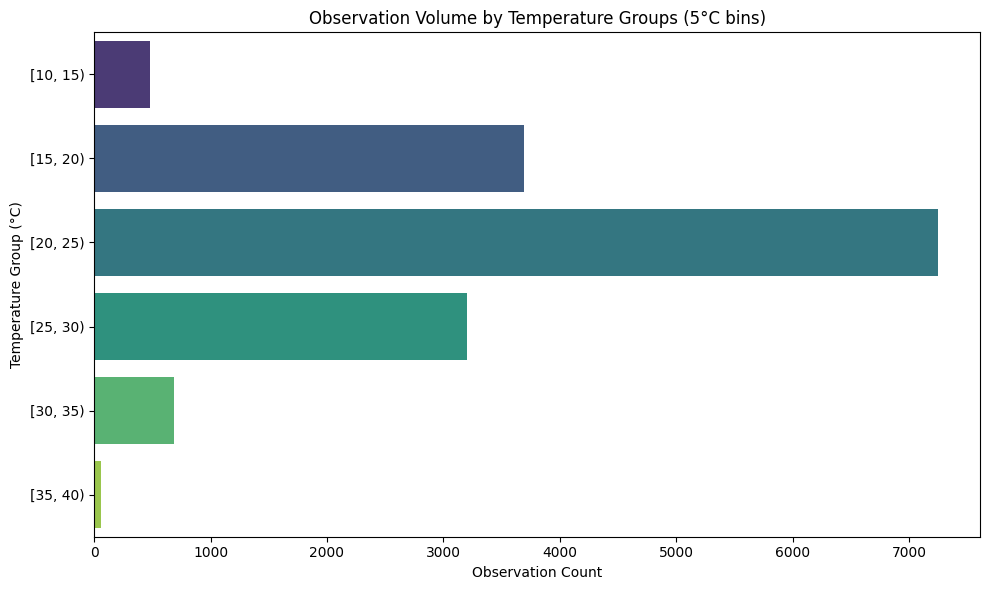

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define 5-degree bins from 10 to 40
bins = range(10, 45, 5)  # 10, 15, 20, 25, 30, 35, 40

# Create the bins (left-inclusive, right-exclusive by default)
combined_df['Temp_Group'] = pd.cut(combined_df['Temperature'], bins=bins, right=False)

# Count observations per temperature group
temp_group_counts = combined_df.groupby('Temp_Group').size().reset_index(name='Observation_Count')

# Convert bin intervals to string labels for plotting
temp_group_counts['Temp_Group_Label'] = temp_group_counts['Temp_Group'].astype(str)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=temp_group_counts, x='Observation_Count', y='Temp_Group_Label', palette='viridis')
plt.title("Observation Volume by Temperature Groups (5°C bins)")
plt.xlabel("Observation Count")
plt.ylabel("Temperature Group (°C)")
plt.tight_layout()
plt.show()


In [25]:
combined_df.head(1)

,Admin_Unit_Code,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,Visit,Interval_Length,...,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt,Habitat_Type,Temp_Group
0,ANTI,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,2.5,...,False,True,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,Forest,"[15, 20)"


In [27]:
min_humidity = combined_df['Humidity'].min()
max_humidity = combined_df['Humidity'].max()
mean_humidity = combined_df['Humidity'].mean()
median_humidity = combined_df['Humidity'].median()

print(f"Min Humidity: {min_humidity}")
print(f"Max Humidity: {max_humidity}")
print(f"Mean Humidity: {mean_humidity}")
print(f"Median Humidity: {median_humidity}")



Min Humidity: 7.30000019073486
Max Humidity: 98.8000030517578
Mean Humidity: 74.15776281236423
Median Humidity: 76.5999984741211


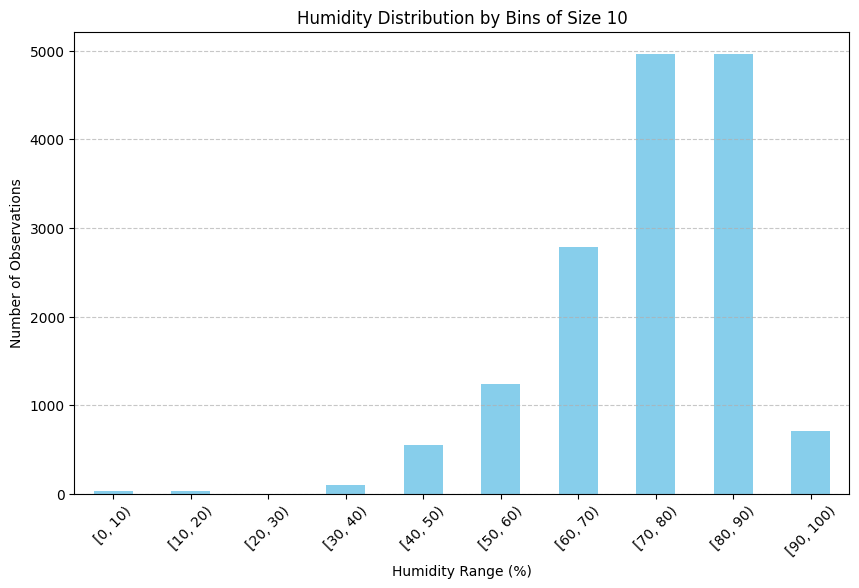

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define bins from 0 to 100 in steps of 10
bins = np.arange(0, 110, 10)

# Create humidity bins
combined_df['Humidity_Bin'] = pd.cut(combined_df['Humidity'], bins=bins, right=False)

# Count values in each bin
bin_counts = combined_df['Humidity_Bin'].value_counts().sort_index()

# Plotting
plt.figure(figsize=(10,6))
bin_counts.plot(kind='bar', color='skyblue')
plt.title('Humidity Distribution by Bins of Size 10')
plt.xlabel('Humidity Range (%)')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()




In [32]:
combined_df.head()

,Admin_Unit_Code,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,Visit,Interval_Length,...,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt,Habitat_Type,Temp_Group,Humidity_Bin
0,ANTI,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,2.5,...,True,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,Forest,"[15, 20)","[70, 80)"
1,ANTI,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,2.5,...,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,Forest,"[15, 20)","[70, 80)"
2,ANTI,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,5.0,...,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,Forest,"[15, 20)","[70, 80)"
3,ANTI,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,5.0,...,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,Forest,"[15, 20)","[70, 80)"
4,ANTI,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,5.0,...,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,Forest,"[15, 20)","[70, 80)"


In [39]:
print(combined_df.columns)



Index(['Admin_Unit_Code', 'Plot_Name', 'Location_Type', 'Year', 'Date',
       'Start_Time', 'End_Time', 'Observer', 'Visit', 'Interval_Length',
       'ID_Method', 'Distance', 'Flyover_Observed', 'Sex', 'Common_Name',
       'Scientific_Name', 'AcceptedTSN', 'AOU_Code', 'PIF_Watchlist_Status',
       'Regional_Stewardship_Status', 'Temperature', 'Humidity', 'Sky', 'Wind',
       'Disturbance', 'Initial_Three_Min_Cnt', 'Habitat_Type', 'Temp_Group',
       'Humidity_Bin'],
      dtype='object')


In [42]:
print(combined_df['Visit'].unique())
print(combined_df['Visit'].value_counts())


[1 2 3]
Visit
1    6854
2    6408
3    2106
Name: count, dtype: int64


In [44]:
# Number of unique species per visit
species_per_visit = combined_df.groupby('Visit')['Common_Name'].nunique()

# Total observations (rows) per visit
obs_per_visit = combined_df.groupby('Visit').size()

print(species_per_visit)
print(obs_per_visit)



Visit
1    118
2     99
3     74
Name: Common_Name, dtype: int64
Visit
1    6854
2    6408
3    2106
dtype: int64


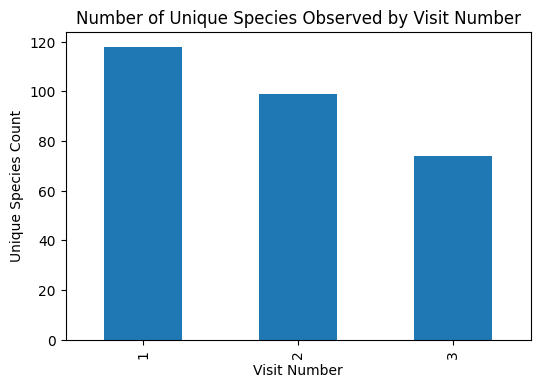

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
species_per_visit.plot(kind='bar')
plt.title('Number of Unique Species Observed by Visit Number')
plt.xlabel('Visit Number')
plt.ylabel('Unique Species Count')
plt.show()


In [49]:
# Drop duplicates and filter where stewardship status is True
common_names_true = combined_df[
    combined_df['Regional_Stewardship_Status'] == True
][['Common_Name']].drop_duplicates().sort_values(by='Common_Name')

print("Common Names (Regional Stewardship = True):")
print(common_names_true)



Common Names (Regional Stewardship = True):
                  Common_Name
75         Acadian Flycatcher
1363        Belted Kingfisher
9028            Blue Grosbeak
1144           Brown Thrasher
11         Carolina Chickadee
2422            Chimney Swift
23           Downy Woodpecker
0              Eastern Towhee
12         Eastern Wood-Pewee
9               Field Sparrow
337            Hooded Warbler
14             Indigo Bunting
2499         Kentucky Warbler
456     Louisiana Waterthrush
2004             Pine Warbler
4321          Prairie Warbler
210           Scarlet Tanager
127               Wood Thrush
533       Worm-eating Warbler
89      Yellow-throated Vireo
1374  Yellow-throated Warbler


C:\Users\tanishq\AppData\Local\Temp\ipykernel_17916\980590535.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=species_counts.values, y=species_counts.index, palette='inferno')


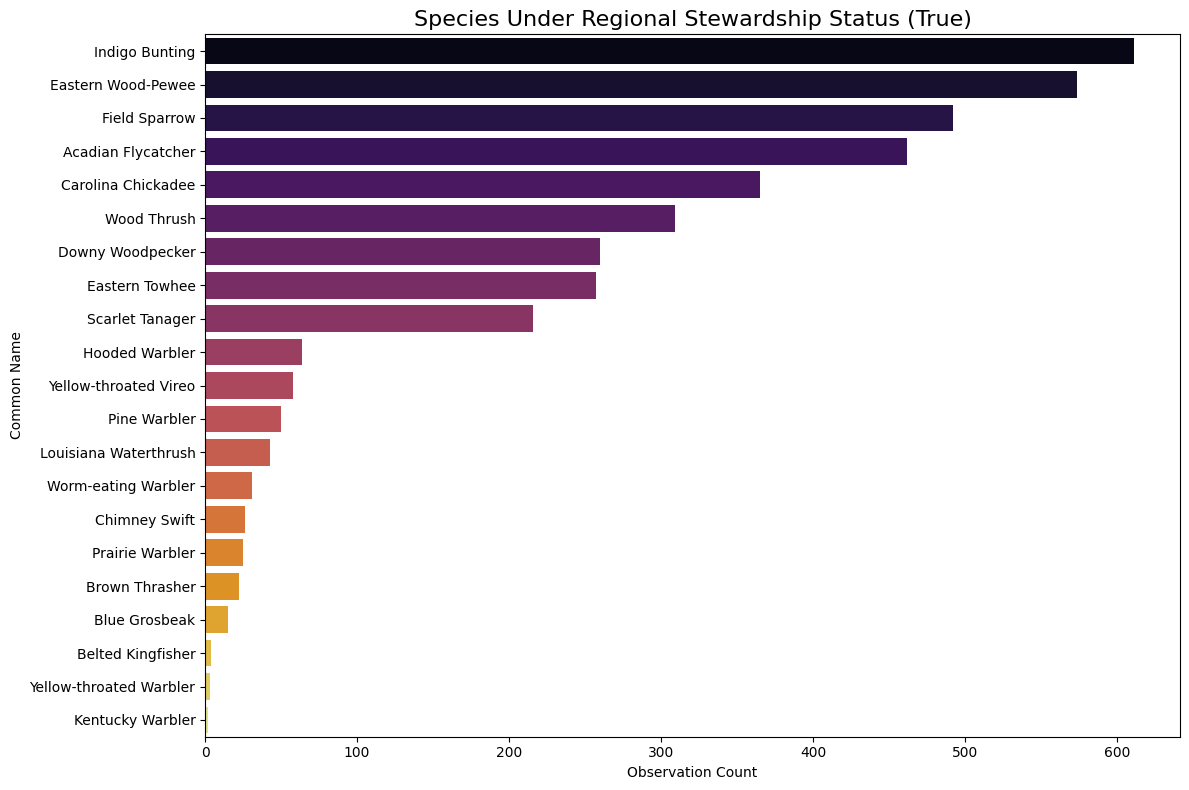

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for True values and count occurrences
steward_df = combined_df[combined_df['Regional_Stewardship_Status'] == True]
species_counts = steward_df['Common_Name'].value_counts().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x=species_counts.values, y=species_counts.index, palette='inferno')
plt.title("Species Under Regional Stewardship Status (True)", fontsize=16)
plt.xlabel("Observation Count")
plt.ylabel("Common Name")
plt.tight_layout()
plt.show()
